In [106]:
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import importlib
#from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import sat_utils as su
from albatros_analysis.scripts.xcorr import helper as hxc
importlib.reload(su)
importlib.reload(butils)

<module 'albatros_analysis.src.utils.baseband_utils' from '/home/thomasb/albatros_analysis/src/utils/baseband_utils.py'>

In [ ]:
from albatros_analysis.src.utils import 

In [107]:
path_config = '/home/thomasb/albatros_analysis/scripts/orbcomm/config/nov25_batch_1762272160.json'

In [108]:
#open up config info for batch
with open(path_config, 'r') as f:
    config = json.load(f)

ant_names = ['MARS1']
ant_coords = [[79.41716147, -90.76723869, 187.9577]]
ant_paths = ['/project/rrg-sievers/albatros/mars/202507/mars1']
clock_offset = [-1]

for i, (ant, details) in enumerate(config["antennas"].items()):
    print(ant, details)
    ant_coords.append(details['coordinates'])
    ant_paths.append(details["path"])
    ant_names.append(details["name"])
    clock_offset.append(details['clock_offset'])
batch_start_ts = config['correlation']['start_timestamp']
batch_end_ts = config['correlation']['end_timestamp']
print(batch_start_ts, batch_end_ts)

MARS2 {'name': 'MARS2', 'path': '/project/rrg-sievers/albatros/mars/202507/mars2/baseband', 'coordinates': [79.41719805, -90.75873919, 183.0684], 'clock_offset': 0}
MARS4 {'name': 'MARS4', 'path': '/project/rrg-sievers/albatros/mars/202507/mars4/baseband', 'coordinates': [79.38845641, -91.01920296, 25.1938], 'clock_offset': -336928}
MARS5 {'name': 'MARS5', 'path': '/project/rrg-sievers/albatros/mars/202507/mars5', 'coordinates': [79.41830257, -90.66739545, 59.6242], 'clock_offset': -431335}
MARS6 {'name': 'MARS6', 'path': '/project/rrg-sievers/albatros/mars/202507/mars6/baseband', 'coordinates': [79.39798424, -90.79984241, 41.699], 'clock_offset': -8595}
MARS7 {'name': 'MARS7', 'path': '/project/rrg-sievers/albatros/mars/202507/mars7/baseband', 'coordinates': [79.41147412, -90.69526613, 31.6314], 'clock_offset': -231359}
MARS8 {'name': 'MARS8', 'path': '/project/rrg-sievers/albatros/mars/202507/mars8/baseband', 'coordinates': [79.44375769, -90.71820263, 414.9131], 'clock_offset': -2288

In [109]:
#open up pulse info for batch
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'
path_pulses = os.path.join(path_batch, 'data/pulses.json')
with open(path_pulses, 'r') as f:
    list_pulses = json.load(f)
times_pulses = []
for p in list_pulses:
    times_pulses.append([p['t_start'], p['t_end']])

0
1762272090 1762358430
raw file ant 0 ['/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272138.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272191.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272246.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272299.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272352.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272408.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272461.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272513.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272569.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272622.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762272675.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/17622

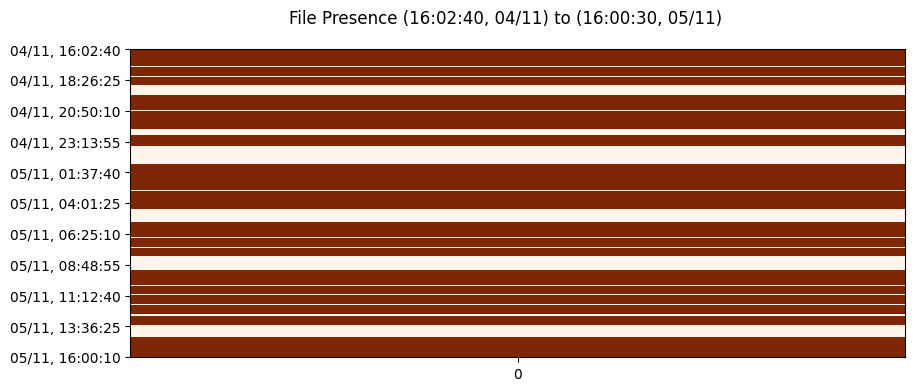

In [ ]:
arr, fig = butils.get_present_files(batch_start_ts, batch_end_ts, [ant_paths[0]], T_SCAN = 5)
runs = butils.get_simul_files(arr, batch_start_ts, 5, [0])

In [187]:
runidx= 3
r = runs[runidx]
rstart, rend = r[0], r[1]
print(rstart, rend)

1762279935 1762282350


In [188]:
#check for holes
cuts = 0
error = butils.check_data_holes(rstart, rend, ant_paths[0], min_filesize=500001224, tol = 60, verbose=False, force_ts = False)
while error:
    print('CUTTING')
    rend = rend-60
    cuts +=1
    error = butils.check_data_holes(rstart, rend, ant_paths[0], min_filesize=500001224, tol = 60, verbose=False, force_ts = False)
print(f'had to cut {cuts} times')

1762279934 1762282297
ERROR: Something wrong near file: /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17622/1762282297.raw
CUTTING
1762279934 1762282244
diff to start -1
diff to end 46
diff between [53 54 53 53 55 53 54 53 54 56 52 54 52 56 52 53 56 52 54 55 53 54 54 53
 56 52 54 52 55 53 55 54 53 52 56 53 54 53 54 55 53 53 55]
No holes in data
had to cut 1 times


In [189]:
overflows = hxc.get_overflow_files(rstart, rend, ant_paths[0])
if overflows.size>0:
    print('OVERFLOW!! NOO!!')
else:
    print('No overflows')

1762279935 1762282290
Using delta of 64.0 seconds to check for gaps between files
No overflows


In [190]:
print('RUN START', rstart)
print('RUN END', rend)
print('RUN LENGTH', (rend-rstart)/60, 'min')

RUN START 1762279935
RUN END 1762282290
RUN LENGTH 39.25 min


In [191]:
contained_pass = []
tol = 100

for start, end in times_pulses:
    inside = start > rstart and end < rend
    overlap_end = end > rend and start < rend - tol
    overlap_start = start < rstart and end > rstart + tol

    if overlap_start or overlap_end or inside:
        contained_pass.append([start, end])

print(contained_pass)
if len(contained_pass) ==0:
    print('NO OVERLAPS: MUST CONTINUE TO NEXT RUN')

[[1762280390, 1762280684]]


## Make a config file

In [192]:
# MAKE CONFIG FILE
#make the config files
file = {}

antennas = {}
nant = len(ant_names)
for j in range(nant):
    antennas[ant_names[j]] = {}
    antennas[ant_names[j]]["name"] = ant_names[j]
    antennas[ant_names[j]]["path"] = ant_paths[j]
    antennas[ant_names[j]]["coordinates"] = list(ant_coords[j])
    antennas[ant_names[j]]['clock_offset'] = clock_offset[j]
file['antennas'] = antennas
file["correlation"] = {
    "start_timestamp": rstart,
    "end_timestamp": rend,
    "vis_acclen": 30000,
    "coarse_acclen": 3000000,
    "osamp": 64,
    "pfb_size": 65536,
    "new_acclen": 1024
}
file["frequency"] = {
    "start_channel": 1834,
    "end_channel": 1852
}

config_path = os.path.join('/home/thomasb/albatros_analysis/scripts/orbcomm/config', f'batch_{batch_start_ts}_mars1_{rstart}.json')
# dump the config files
with open(config_path, 'w') as f:
    json.dump(file, f, indent=4)

In [193]:
# RUN SATDET FROM COMMAND LINE HERE
#  get_satdet.py {config_name} -r 'MARS1' -t 'mars1_{rstart}'

In [194]:
print(config_path)
satdet_path = f'/scratch/thomasb/batch_{batch_start_ts}_m1/{rstart}/satdet'
print(satdet_path)

/home/thomasb/albatros_analysis/scripts/orbcomm/config/batch_1762272160_mars1_1762279935.json
/scratch/thomasb/batch_1762272160_m1/1762279935/satdet


## Check the specnum offsets

In [181]:
with open(os.path.join(satdet_path, 'satdet_3M_refMARS1.json'), 'r') as f:
    satdet = json.load(f)

In [182]:
run_offsets = []
for name, vals in satdet.items():
    if name =='summary':
        continue
    print(name)
    try:
        offs = vals[0]['specnumoffsets']
        print(offs)
        offs = [x for x in offs if x != 0]
    except IndexError:
        offs = 0
    print(offs)
    med = int(np.median(offs))
    print(med)
    run_offsets.append(med)

MARS2
[-143994283, -143994283, -143994283, -143994283]
[-143994283, -143994283, -143994283, -143994283]
-143994283
MARS4
[-144331212, -144331212, 0, -144331211]
[-144331212, -144331212, -144331211]
-144331212
MARS5
[-144425618, 0, 0, 0, -144425618, -144425618]
[-144425618, -144425618, -144425618]
-144425618
MARS6
[-144002878, -144002878, -144002878, 0, 0, 0, -144002877]
[-144002878, -144002878, -144002878, -144002877]
-144002878
MARS7
[-144225642, -144225642, -144225642, -144225642, 0, -144225642, -144225642]
[-144225642, -144225642, -144225642, -144225642, -144225642, -144225642]
-144225642
MARS8
[-144223133, -144223133, -144223133, 0, 0, 0, -144223134]
[-144223133, -144223133, -144223133, -144223134]
-144223133


In [183]:
print(run_offsets)

[-143994283, -144331212, -144425618, -144002878, -144225642, -144223133]


In [184]:
m1_offset = -run_offsets[0]
run_offsets_corr = np.array(run_offsets, dtype=int) - run_offsets[0]

In [185]:
#check that the other make sense:
for i in range(len(run_offsets)):
    print(f'\n{ant_names[i+1]}')
    print('from run (corrected)', run_offsets_corr[i])
    print('from satdet', clock_offset[i+1])
    print('diff', run_offsets_corr[i] - clock_offset[i+1])


MARS2
from run (corrected) 0
from satdet 0
diff 0

MARS4
from run (corrected) -336929
from satdet -336928
diff -1

MARS5
from run (corrected) -431335
from satdet -431335
diff 0

MARS6
from run (corrected) -8595
from satdet -8595
diff 0

MARS7
from run (corrected) -231359
from satdet -231359
diff 0

MARS8
from run (corrected) -228850
from satdet -228851
diff 1


## Save corrected config file

In [186]:
file['antennas']['MARS1']['clock_offset'] = m1_offset
with open(config_path, 'w') as f:
    json.dump(file, f, indent=4)